In [1]:
!pip install osmnx geopandas folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.7 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx

In [3]:
G_osmnx = ox.graph_from_place("Lisboa, Portugal", network_type='drive')
G_osmnx = G_osmnx.to_undirected()


In [4]:
# coordenadas de início e fim
start_coords = (38.70616277991234, -9.145214164271783)
end_coords = (38.758396748040894, -9.153133859419391)

# obter nós mais próximos às coordenadas
orig_node = ox.distance.nearest_nodes(G_osmnx, X=start_coords[1], Y=start_coords[0])
dest_node = ox.distance.nearest_nodes(G_osmnx, X=end_coords[1], Y=end_coords[0])

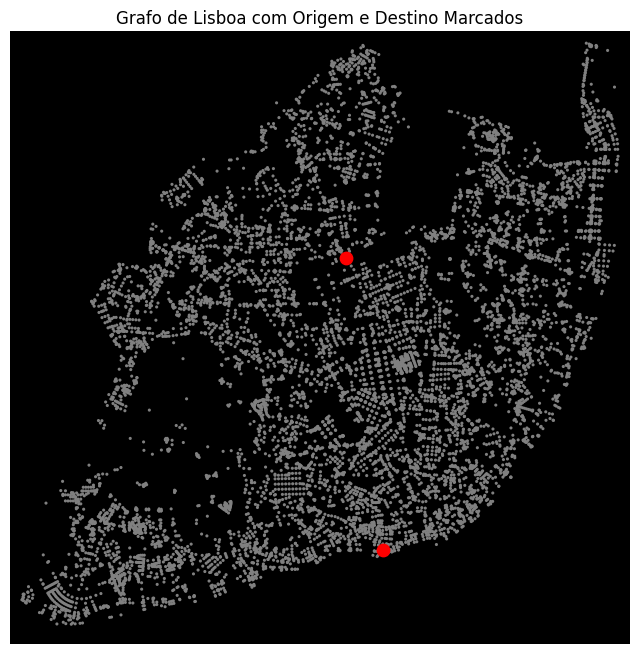

In [5]:
import matplotlib.pyplot as plt

fig, ax = ox.plot_graph(
    G_osmnx,
    node_size=5,
    node_color="gray",
    edge_color="black",
    bgcolor="black",
    show=False,
    close=False
)

# destacar origem e destino em vermelho
nx.draw_networkx_nodes(
    G_osmnx,
    pos={orig_node: (G_osmnx.nodes[orig_node]['x'], G_osmnx.nodes[orig_node]['y']),
         dest_node: (G_osmnx.nodes[dest_node]['x'], G_osmnx.nodes[dest_node]['y'])},
    nodelist=[orig_node, dest_node],
    node_color='red',
    node_size=80,
    ax=ax
)

plt.title("Grafo de Lisboa com Origem e Destino Marcados")
plt.show()


In [6]:
# converter G_osmnx para um grafo estilo dicionário
map_graph = {}
for u, v, data in G_osmnx.edges(data=True):
    weight = data.get("length", 1) # teste com 'travel_time' se quiser depois :D
    map_graph.setdefault(u, []).append((v, weight))
    map_graph.setdefault(v, []).append((u, weight))

note que o grafo contém:

```
21270962: [
    (11407374456, 379.43),
    (245930205, 187.95),
    (5162987186, 111.69)
]
```

o formato que criamos:

```
{
    node_1: [(vizinho_1, peso_1), (vizinho_2, peso_2)],
    node_2: [(vizinho_3, peso_3)],
    ...
}
```

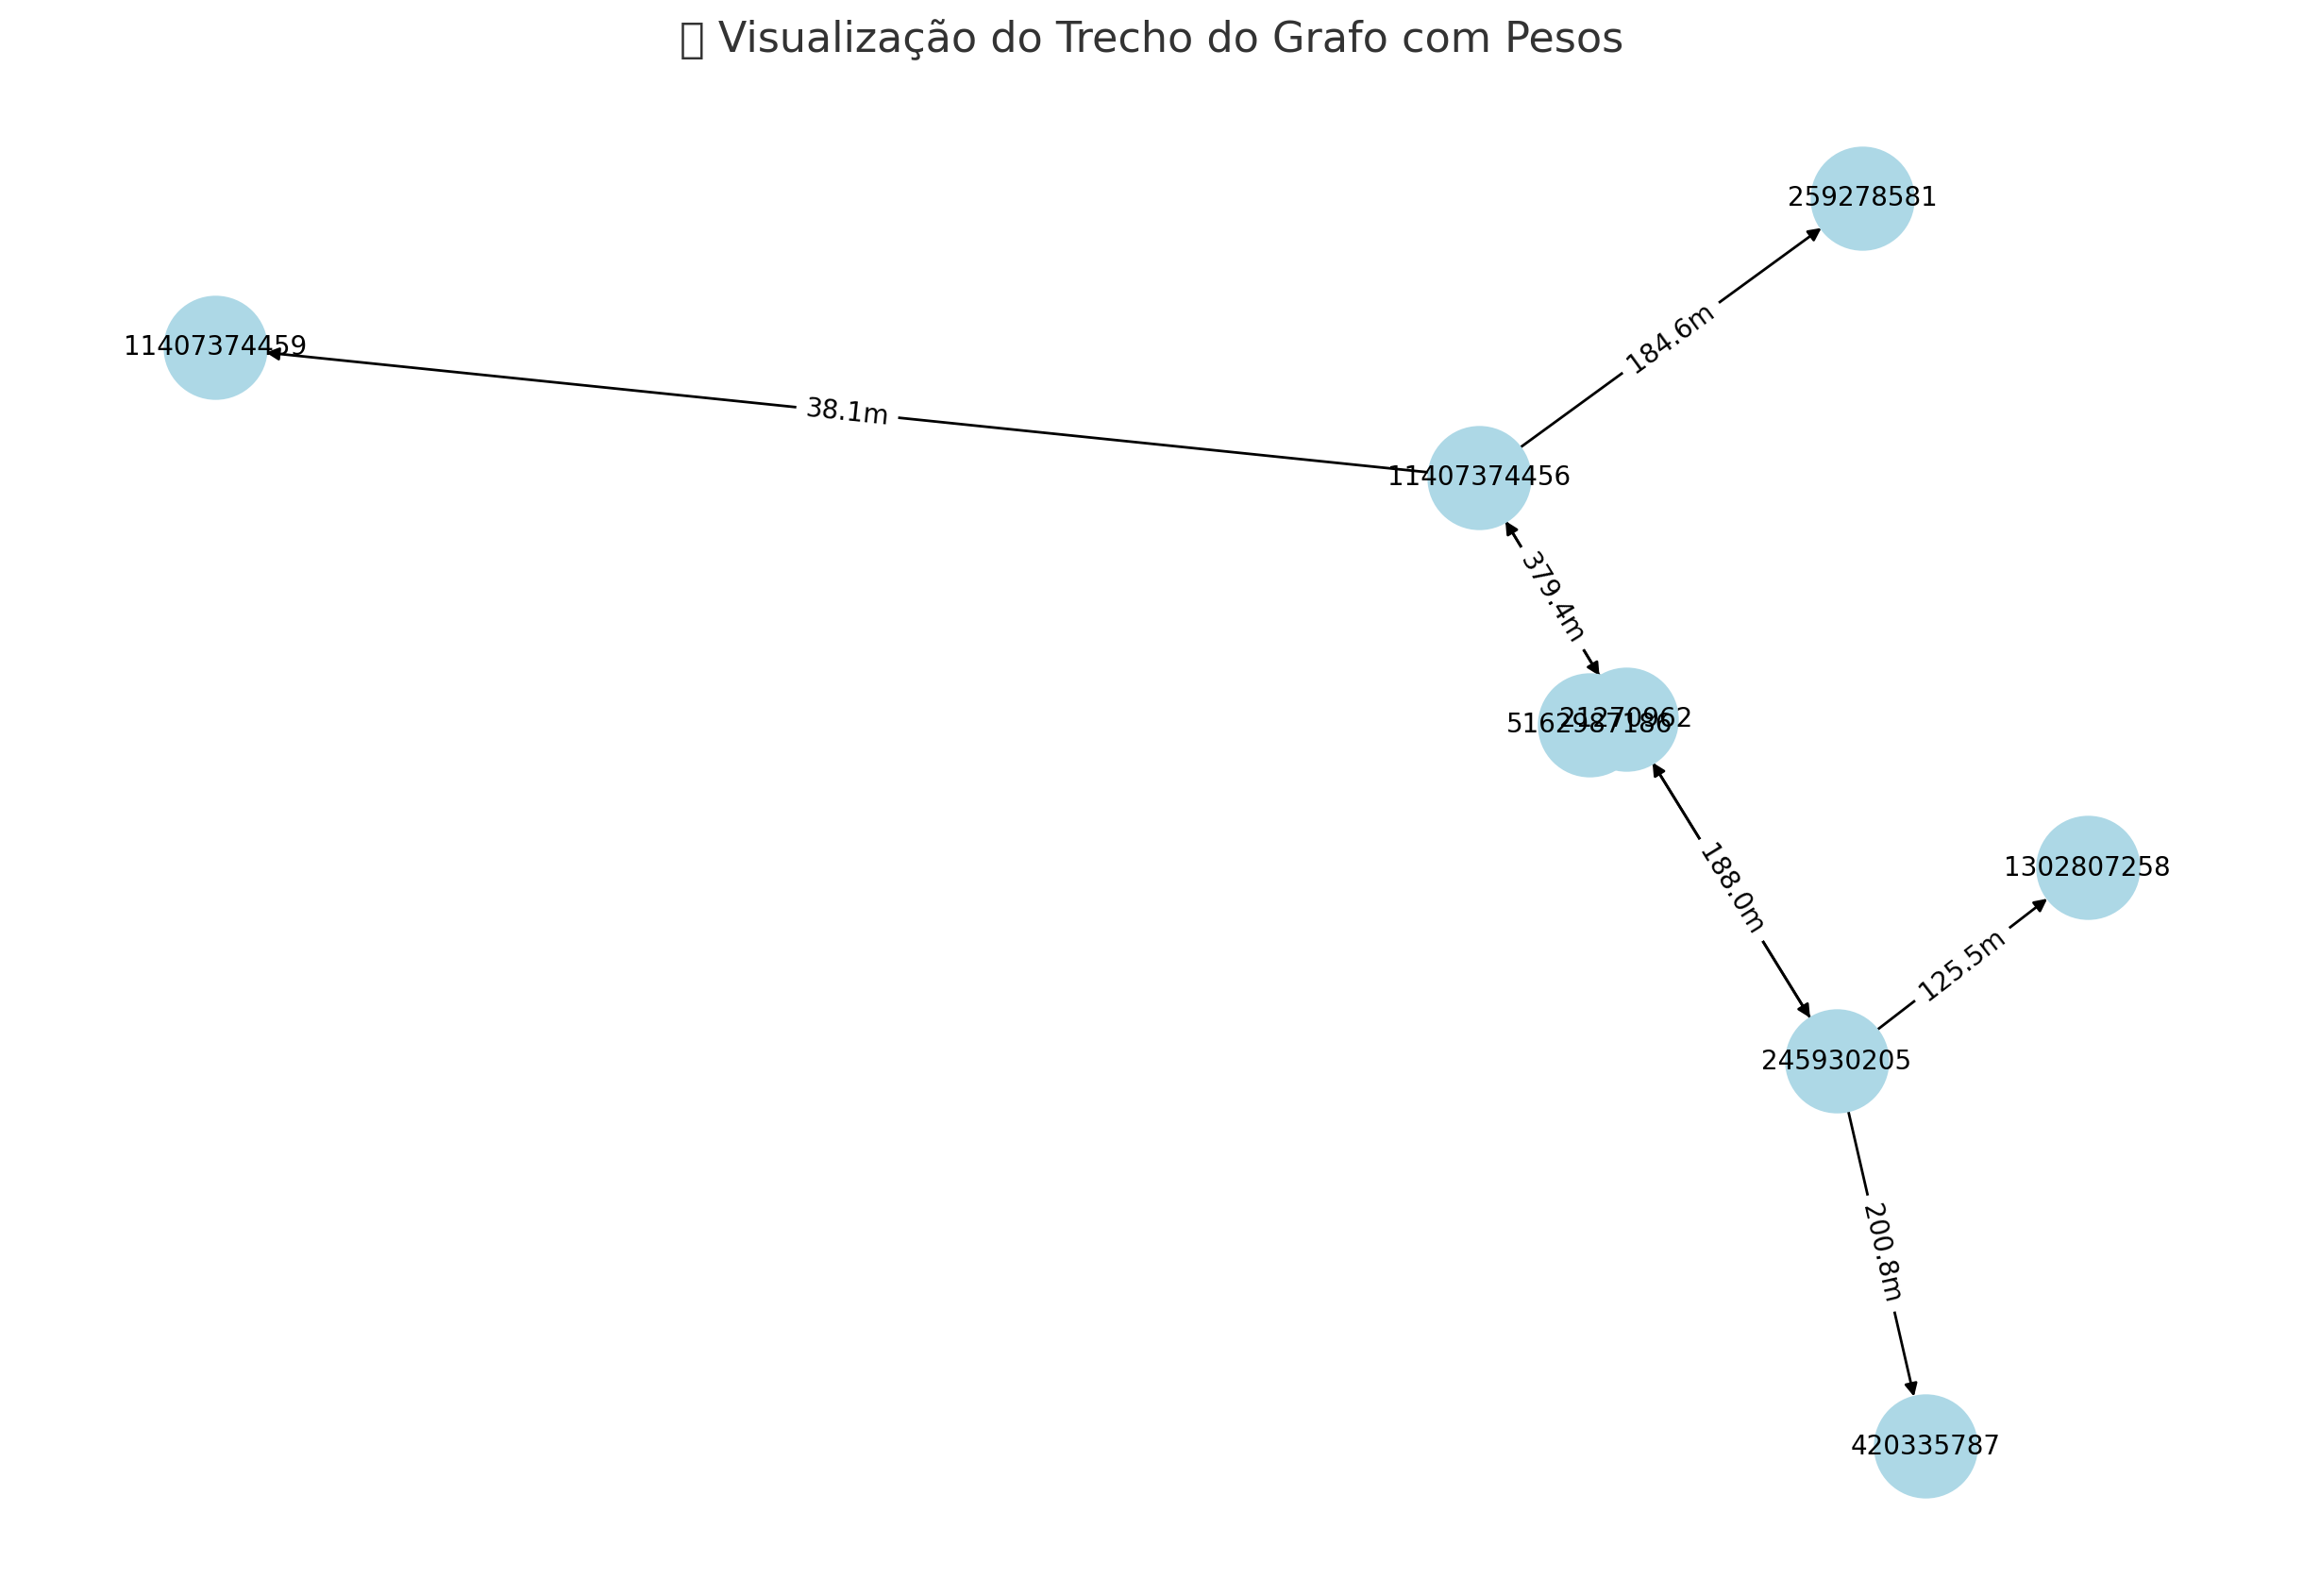

In [10]:
from collections import defaultdict
import heapq

def dijkstra(graph, start):
    # Inicialização
    dist = {node: float('inf') for node in graph}
    dist[start] = 0
    parent = {node: None for node in graph}
    visited = set()

    # Loop principal
    while len(visited) < len(graph):
        # Encontrar o nó não visitado com a menor distância
        current = min((node for node in graph if node not in visited), key=lambda x: dist[x])
        visited.add(current)

        # Atualizar as distâncias dos vizinhos
        for neighbor, weight in graph[current]:
            if neighbor not in visited:
                new_dist = dist[current] + weight
                if new_dist < dist[neighbor]:
                    dist[neighbor] = new_dist
                    parent[neighbor] = current

    return dist, parent

# Executar com nós reais
distances, parents = dijkstra(map_graph, orig_node)

# Reconstruir caminho
def show_path(parents, goal):
    path = []
    while goal is not None:
        path.insert(0, goal)
        goal = parents.get(goal)
    return path

shortest_path = show_path(parents, dest_node)


In [11]:
shortest_path

[4879838319,
 489762977,
 256332392,
 256332542,
 256066316,
 256066317,
 256332842,
 256497819,
 256497820,
 256498341,
 1127052578,
 256328861,
 5331010295,
 4313232021,
 5331010292,
 256489993,
 256490010,
 256490032,
 256331785,
 256490283,
 256331549,
 256490269,
 11445792027,
 11445792028,
 11445792030,
 1130935018,
 247123562,
 1126816499,
 1126816308,
 32172640,
 9324970965,
 1932923495,
 3946903815,
 32172637,
 659576888,
 580276710,
 2463340837,
 1120476711,
 580276682,
 580276694,
 1120318020,
 5960376611,
 1120318491,
 5935614267,
 5935614260,
 1455841721,
 4632541075,
 447565096,
 256582774,
 256582775,
 1127780270,
 1127780300,
 1129605270,
 1129605277,
 1129611927,
 256583721,
 205020736,
 1106603270,
 1106602946,
 205017835,
 1106603399,
 1866351896]

In [12]:
print("Nós de origem e destino:")
print("Origem:", orig_node)
print("Destino:", dest_node)

print("\nCaminho mais curto encontrado:")
print(shortest_path)

print("\nNúmero de nós no caminho:", len(shortest_path))
print("Destino está no caminho?", dest_node in shortest_path)

# Verifique se há nós inválidos
missing_nodes = [n for n in shortest_path if n not in G_osmnx.nodes]
print("Nós inválidos no caminho:", missing_nodes)


Nós de origem e destino:
Origem: 4879838319
Destino: 1866351896

Caminho mais curto encontrado:
[4879838319, 489762977, 256332392, 256332542, 256066316, 256066317, 256332842, 256497819, 256497820, 256498341, 1127052578, 256328861, 5331010295, 4313232021, 5331010292, 256489993, 256490010, 256490032, 256331785, 256490283, 256331549, 256490269, 11445792027, 11445792028, 11445792030, 1130935018, 247123562, 1126816499, 1126816308, 32172640, 9324970965, 1932923495, 3946903815, 32172637, 659576888, 580276710, 2463340837, 1120476711, 580276682, 580276694, 1120318020, 5960376611, 1120318491, 5935614267, 5935614260, 1455841721, 4632541075, 447565096, 256582774, 256582775, 1127780270, 1127780300, 1129605270, 1129605277, 1129611927, 256583721, 205020736, 1106603270, 1106602946, 205017835, 1106603399, 1866351896]

Número de nós no caminho: 62
Destino está no caminho? True
Nós inválidos no caminho: []


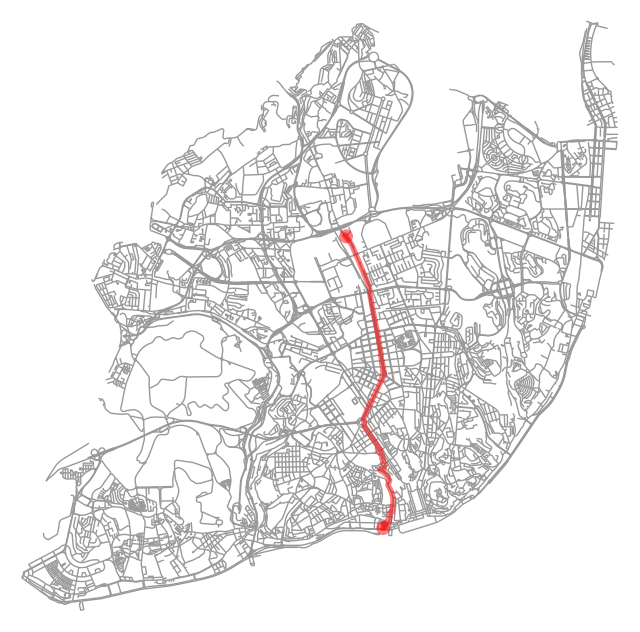

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [13]:
ox.plot_graph_route(G_osmnx, shortest_path, route_linewidth=4, node_size=0, bgcolor='white')

# Vejamos a propagação do algoritmo

In [15]:
def dijkstra(graph, start):
    dist = {node: float('inf') for node in graph}
    dist[start] = 0

    parent = {node: None for node in graph}
    visited = set()
    visited_edges = []

    while len(visited) < len(graph):
        # escolhe o nó não visitado com menor distância
        current = min(
            (node for node in graph if node not in visited),
            key=lambda node: dist[node]
        )

        # se o menor já for infinito, os restantes são inalcançáveis
        if dist[current] == float('inf'):
            break

        visited.add(current)

        # percorre os vizinhos
        for neighbor, weight in graph.get(current, []):
            visited_edges.append((current, neighbor, weight))

            if neighbor not in visited:
                new_dist = dist[current] + weight

                if new_dist < dist.get(neighbor, float('inf')):
                    dist[neighbor] = new_dist
                    parent[neighbor] = current

    return dist, parent, visited_edges


In [16]:
# Dijkstra com arestas visitadas
distances, parents, visited_edges = dijkstra(map_graph, orig_node)
shortest_path = show_path(parents, dest_node)
shortest_edges = list(zip(shortest_path[:-1], shortest_path[1:]))


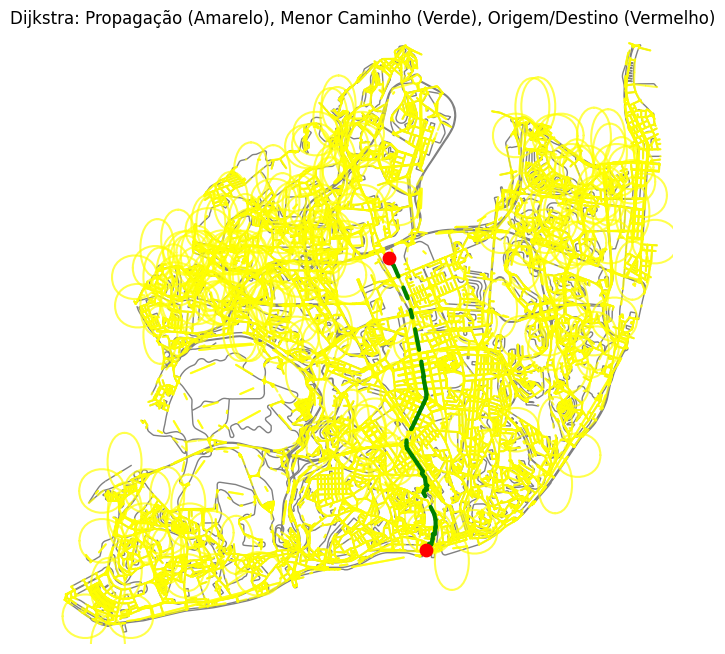

In [17]:
fig, ax = ox.plot_graph(
    G_osmnx,
    node_size=0,
    edge_color="gray",
    bgcolor="white",
    show=False,
    close=False
)

# Desenhar as arestas exploradas em amarelo
nx.draw_networkx_edges(
    G_osmnx,
    pos={n: (G_osmnx.nodes[n]['x'], G_osmnx.nodes[n]['y']) for n in G_osmnx.nodes},
    edgelist=visited_edges,
    edge_color='yellow',
    width=1.5,
    alpha=0.7,
    ax=ax
)

# Desenhar o menor caminho em verde/azul
nx.draw_networkx_edges(
    G_osmnx,
    pos={n: (G_osmnx.nodes[n]['x'], G_osmnx.nodes[n]['y']) for n in G_osmnx.nodes},
    edgelist=shortest_edges,
    edge_color='green',
    width=3,
    ax=ax
)

# Destacar origem e destino
nx.draw_networkx_nodes(
    G_osmnx,
    pos={
        orig_node: (G_osmnx.nodes[orig_node]['x'], G_osmnx.nodes[orig_node]['y']),
        dest_node: (G_osmnx.nodes[dest_node]['x'], G_osmnx.nodes[dest_node]['y'])
    },
    nodelist=[orig_node, dest_node],
    node_color='red',
    node_size=80,
    ax=ax
)

plt.title("Dijkstra: Propagação (Amarelo), Menor Caminho (Verde), Origem/Destino (Vermelho)")
plt.show()


# Vamos dar uma olhadinha no mapa :)

In [18]:
import geopandas as gpd
from shapely.geometry import LineString

# criar geometrias a partir do menor caminho
lines = [LineString([(G_osmnx.nodes[u]['x'], G_osmnx.nodes[u]['y']),
                     (G_osmnx.nodes[v]['x'], G_osmnx.nodes[v]['y'])]) for u, v in shortest_edges]

# criar GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=lines)
gdf.set_crs(epsg=4326, inplace=True)

# exportar para GeoJSON
gdf.to_file("shortest_path.geojson", driver='GeoJSON')



In [21]:
import folium
#m = folium.Map(location=start_coords, zoom_start=13)

m = folium.Map(
    location=start_coords,
    zoom_start=13,
    tiles="CartoDB Voyager"
)

# adicionar rota
folium.PolyLine([(G_osmnx.nodes[n]['y'], G_osmnx.nodes[n]['x']) for n in shortest_path],
                color="green", weight=5, opacity=0.8).add_to(m)

# marcar origem e destino
folium.Marker(start_coords, popup="Origem", icon=folium.Icon(color='red')).add_to(m)
folium.Marker(end_coords, popup="Destino", icon=folium.Icon(color='red')).add_to(m)

m.save("rota_interativa.html")
m
